# SWOT annual time-mean SSH — Dask parallel version

This notebook is inspired by the configuration / Dask-cluster setup of
**Global_SSH_spectra_dask.ipynb**, but the goal here is different: instead of
computing along-track wavenumber spectra, it computes the **time-mean SSH**
over a full year of SWOT data (one sub-directory per month) on a regular
lat/lon grid, and saves it to disk.

The saved mean is meant to be reused later as the reference against which
individual SWOT passes are compared to obtain SSH anomalies and, from there,
SSH variance (`variance = mean[(ssh - time_mean)**2]`, accumulated the same
way as the mean itself, in a follow-up notebook).


In [1]:
import glob
import os
import re
import warnings
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ── Dask ─────────────────────────────────────────────────────────────────────
import dask
from dask.distributed import Client, LocalCluster, progress, wait

from swot_analysis import load_swot_l2_expert


## 1. Configuration

In [14]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR    = '/Volumes/PortableSSD/'#'/Users/zoecas/Documents/data/'


# ── One sub-directory per month of the year to average over ────────────────
DATA_SUBDIRS = ['SWOT_L2_LR_SSH_Expert_0424/',
                'SWOT_L2_LR_SSH_Expert_0524/',
                'SWOT_L2_LR_SSH_Expert_0624/',
                'SWOT_L2_LR_SSH_Expert_0724/',
                'SWOT_L2_LR_SSH_Expert_0824/',
                'SWOT_L2_LR_SSH_Expert_0924/',
                'SWOT_L2_LR_SSH_Expert_1024/',
                'SWOT_L2_LR_SSH_Expert_1124/',
                'SWOT_L2_LR_SSH_Expert_1224/',
                'SWOT_L2_LR_SSH_Expert_0125/',
                'SWOT_L2_LR_SSH_Expert_0225/',
                'SWOT_L2_LR_SSH_Expert_0325/',
               'SWOT_L2_LR_SSH_Expert_0425/',]

FILE_PATTERN = 'SWOT_L2_LR_SSH_Expert_*.nc'


def parse_year_month(subdir_name, overrides=None):
    """
    Infer (year, month) from a sub-directory name.

    Default rule: the trailing 4 digits are read as MMYY, e.g.
    'SWOT_L2_0225' -> month=2, year=2025.

    For directories that don't follow this convention, pass a dict via
    `overrides` mapping subdir name -> (year, month); it takes precedence
    over the automatic parsing.
    """
    if overrides and subdir_name in overrides:
        return overrides[subdir_name]
    name = subdir_name.rstrip('/').rstrip('\\')
    match = re.search(r'(\d{2})(\d{2})$', name)
    if not match:
        raise ValueError(
            f"Could not infer year/month from subdirectory name '{subdir_name}'. "
            f"Add an explicit entry to DATA_SUBDIR_OVERRIDES instead."
        )
    mm, yy = match.groups()
    month = int(mm)
    year = 2000 + int(yy)
    if not (1 <= month <= 12):
        raise ValueError(f"Parsed invalid month={month} from '{subdir_name}'.")
    return year, month

# Manual overrides for sub-directories that don't follow the MMYY naming
# convention above, e.g. {'my_weird_folder_name': (2025, 7)}
DATA_SUBDIR_OVERRIDES = {}

# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0, 60.0
LON_MIN, LON_MAX = 0.0, 360.0

# ── Averaging grid ─────────────────────────────────────────────────────────────
# Resolution of the regular lat/lon grid the mean is accumulated on.
# Keep this coarse-ish (>= 0.25°) unless you have a reason not to: the grid
# arrays are shipped from every worker back to the scheduler once per file,
# so a very fine grid multiplies both memory and network traffic across the
# whole year of files. A 1° grid over this region is ~120 x 360 cells,
# i.e. a few hundred KB per file result — no problem at all.
GRID_DEG = 1.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)

# ── Output ───────────────────────────────────────────────────────────────────
OUTPUT_NC = 'swot_ssh_time_mean_0424_0425.nc'

# ── Dask cluster parameters ───────────────────────────────────────────────────
N_WORKERS          = 4       # number of worker processes
THREADS_PER_WORKER = 1       # do NOT increase, core functions contain lops
MEMORY_LIMIT       = '4GB'   # per worker RAM cap


## 2. Start the Dask cluster and open the Dashboard

**`LocalCluster`** spawns `N_WORKERS` independent Python processes on the same machine.

> Warning: keep `threads_per_worker=1`:
> the underlying HDF5/netCDF4 library is not thread-safe for concurrent reads
> from the same process. Each worker uses one thread, and processes are
> isolated from one another, so there is no contention on either count.


In [5]:
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    dashboard_address=':8787',
)
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client   # displays the interactive widget in JupyterLab


/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55574 instead
  warnings.warn(


Dashboard: http://127.0.0.1:55574/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:55574/status,
Dashboard: http://127.0.0.1:55574/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55575,Workers: 0
Dashboard: http://127.0.0.1:55574/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:55589,Total threads: 1
Dashboard: http://127.0.0.1:55590/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:55578,


2026-07-22 16:39:42,091 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:55586'.
2026-07-22 16:39:42,391 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:55588'.


## 3. Grid definition and worker function

Instead of returning per-segment spectra, each worker task bins the raw
`ssha` values of one granule onto the fixed lat/lon grid and returns a
**partial sum** and a **partial count** per grid cell (plus how many valid
pixels it used). Summing these across all files and dividing
`sum_total / count_total` at the end gives the time mean — this is a simple,
numerically stable one-pass streaming average that works no matter how many
files are processed, without ever holding more than one file's data in
memory at a time.


In [6]:
def build_grid_edges(lat_min, lat_max, lon_min, lon_max, grid_deg):
    lat_edges = np.arange(lat_min, lat_max + grid_deg, grid_deg)
    lon_edges = np.arange(lon_min, lon_max + grid_deg, grid_deg)
    return lat_edges, lon_edges


def accumulate_one_file(filepath, ssh_var, hret,
                         lat_min, lat_max, lon_min, lon_max,
                         lat_edges, lon_edges):
    """
    Dask worker task: load one Expert granule and bin its ssha values onto
    the (lat_edges, lon_edges) grid.

    Returns (filepath, sum_grid, count_grid, n_valid_pixels).
    On any error returns (filepath, error_string, None, None) so one bad
    granule never cancels the whole computation.
    """
    import numpy as np
    import traceback as _tb
    from swot_analysis import load_swot_l2_expert

    nlat = len(lat_edges) - 1
    nlon = len(lon_edges) - 1
    sum_grid   = np.zeros((nlat, nlon), dtype=np.float64)
    count_grid = np.zeros((nlat, nlon), dtype=np.int64)

    try:
        data = load_swot_l2_expert(filepath, ssh_var=ssh_var, HRET=hret)
    except Exception:
        return (filepath, f'load error:\n{_tb.format_exc()}', None, None)

    try:
        ssha = np.asarray(data['ssha']).ravel()
        lat  = np.asarray(data['latitude']).ravel()
        lon  = np.mod(np.asarray(data['longitude']).ravel(), 360.0)

        valid = (np.isfinite(ssha) & np.isfinite(lat) & np.isfinite(lon) &
                 (lat >= lat_min) & (lat <= lat_max) &
                 (lon >= lon_min) & (lon <= lon_max))

        if np.any(valid):
            ssha_v, lat_v, lon_v = ssha[valid], lat[valid], lon[valid]

            lat_idx = np.clip(np.digitize(lat_v, lat_edges) - 1, 0, nlat - 1)
            lon_idx = np.clip(np.digitize(lon_v, lon_edges) - 1, 0, nlon - 1)

            np.add.at(sum_grid,   (lat_idx, lon_idx), ssha_v)
            np.add.at(count_grid, (lat_idx, lon_idx), 1)
    except Exception:
        return (filepath, f'binning error:\n{_tb.format_exc()}', None, None)

    return (filepath, sum_grid, count_grid, int(valid.sum()))


## 4. Build the file list across all monthly sub-directories

In [9]:
lat_edges, lon_edges = build_grid_edges(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, GRID_DEG)
nlat, nlon = len(lat_edges) - 1, len(lon_edges) - 1
print(f'Grid: {nlat} x {nlon} cells at {GRID_DEG}° resolution.')

filepaths = []
file_year_month = []

for subdir in DATA_SUBDIRS:
    year, month = parse_year_month(subdir, overrides=DATA_SUBDIR_OVERRIDES)
    subdir_files = sorted(glob.glob(os.path.join(DATA_DIR, subdir, FILE_PATTERN)))
    print(f'{subdir:30s} -> {len(subdir_files):4d} files  (year={year}, month={month:02d})')
    filepaths.extend(subdir_files)
    file_year_month.extend([(year, month)] * len(subdir_files))

print(f'\n{len(filepaths)} Expert granule files found across {len(DATA_SUBDIRS)} sub-directories.')


Grid: 120 x 360 cells at 1.0° resolution.
SWOT_L2_LR_SSH_Expert_0424/    ->  837 files  (year=2024, month=04)
SWOT_L2_LR_SSH_Expert_0524/    ->  860 files  (year=2024, month=05)
SWOT_L2_LR_SSH_Expert_0624/    ->  835 files  (year=2024, month=06)
SWOT_L2_LR_SSH_Expert_0724/    ->  859 files  (year=2024, month=07)
SWOT_L2_LR_SSH_Expert_0824/    ->  869 files  (year=2024, month=08)
SWOT_L2_LR_SSH_Expert_0924/    ->  834 files  (year=2024, month=09)
SWOT_L2_LR_SSH_Expert_1024/    ->  859 files  (year=2024, month=10)
SWOT_L2_LR_SSH_Expert_1124/    ->  835 files  (year=2024, month=11)
SWOT_L2_LR_SSH_Expert_1224/    ->  866 files  (year=2024, month=12)
SWOT_L2_LR_SSH_Expert_0125/    ->  807 files  (year=2025, month=01)
SWOT_L2_LR_SSH_Expert_0225/    ->  784 files  (year=2025, month=02)
SWOT_L2_LR_SSH_Expert_0325/    ->  863 files  (year=2025, month=03)
SWOT_L2_LR_SSH_Expert_0425/    ->  826 files  (year=2025, month=04)

10934 Expert granule files found across 13 sub-directories.


## 5. Parallel accumulation with Dask

Each worker returns one `(nlat, nlon)` sum array and one `(nlat, nlon)`
count array per file. These are tiny at `GRID_DEG = 1.0` (a few hundred KB),
so shipping one pair per file back to the scheduler is cheap even over a
full year of granules.

> Open `http://localhost:8787` in a browser tab **before** running this cell.


In [10]:
import functools

worker_fn = functools.partial(
    accumulate_one_file,
    ssh_var=SSH_VAR,
    hret=HRET,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
    lat_edges=lat_edges, lon_edges=lon_edges,
)

futures = client.map(worker_fn, filepaths)

# Live progress bar inside the notebook (also visible on the Dashboard)
progress(futures)

# Block until all futures are complete
wait(futures)


DoneAndNotDoneFutures(done={<Future: finished, type: tuple, key: accumulate_one_file-a0dc0ecb8474f1e22686aeb530e9ec42>, <Future: finished, type: tuple, key: accumulate_one_file-f401ffba0ee29f9f0e120310b0165700>, <Future: finished, type: tuple, key: accumulate_one_file-b2feb4cb2fc41ea3c0e118742822566e>, <Future: finished, type: tuple, key: accumulate_one_file-fab3bbae4cdbb4cf5485385144de0742>, <Future: finished, type: tuple, key: accumulate_one_file-ba6475510b06ac4c144d523edc508b9f>, <Future: finished, type: tuple, key: accumulate_one_file-8fb400ddf75618de38644d76a27f95a4>, <Future: finished, type: tuple, key: accumulate_one_file-03a88b4d543dfd6c3eaf1671ecb34040>, <Future: finished, type: tuple, key: accumulate_one_file-ac27f98e4c73f310a8b3c78bbb214bcf>, <Future: finished, type: tuple, key: accumulate_one_file-cf4d65271b6ccb0155f6b7f293e42a60>, <Future: finished, type: tuple, key: accumulate_one_file-4b88532a766e805aabb99135a97b83ca>, <Future: finished, type: tuple, key: accumulate_one_

## 6. Gather and reduce

Results are summed into two running totals (`sum_total`, `count_total`) as
they come back — this keeps memory in the main process bounded to just the
grid size, regardless of how many files were processed.


In [11]:
raw_results = client.gather(futures)

sum_total   = np.zeros((nlat, nlon), dtype=np.float64)
count_total = np.zeros((nlat, nlon), dtype=np.int64)
n_pixels_total = 0
skipped = []

for (filepath, sum_grid, count_grid, n_valid), (year, month) in zip(raw_results, file_year_month):
    if isinstance(sum_grid, str):                 # error string
        skipped.append((filepath, sum_grid))
        continue
    sum_total   += sum_grid
    count_total += count_grid
    n_pixels_total += n_valid

print(f'Done. {n_pixels_total} valid pixels accumulated from '
      f'{len(filepaths) - len(skipped)} file(s).')
print(f'{len(skipped)} file(s) skipped.')
if skipped:
    for name, err in skipped:
        print(f'  {name}: {err}')

print(f'\nGrid cells with at least one observation: '
      f'{int((count_total > 0).sum())} / {count_total.size}')


Done. 2732549770 valid pixels accumulated from 10934 file(s).
0 file(s) skipped.

Grid cells with at least one observation: 32880 / 43200


## 7. Build the time-mean dataset

In [12]:
with np.errstate(invalid='ignore', divide='ignore'):
    mean_grid = np.where(count_total > 0, sum_total / count_total, np.nan)

lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])

years  = sorted(set(y for y, m in file_year_month))
months = sorted(set(m for y, m in file_year_month))

ds_mean = xr.Dataset(
    data_vars=dict(
        ssh_mean=(['lat', 'lon'], mean_grid,
                  {'long_name': f'Time-mean {SSH_VAR}', 'units': 'm'}),
        n_obs=(['lat', 'lon'], count_total,
               {'long_name': 'Number of valid pixels accumulated per cell'}),
    ),
    coords=dict(
        lat=('lat', lat_centers, {'units': 'degrees_north'}),
        lon=('lon', lon_centers, {'units': 'degrees_east'}),
    ),
    attrs=dict(
        description='Time-mean SWOT SSH accumulated over multiple monthly '
                     'sub-directories, for later use as the reference to '
                     'compute SSHA variance.',
        ssh_var=SSH_VAR,
        hret_correction=str(HRET),
        grid_deg=GRID_DEG,
        n_files_used=len(filepaths) - len(skipped),
        n_files_skipped=len(skipped),
        years_covered=str(years),
        months_covered=str(months),
        data_subdirs=str(DATA_SUBDIRS),
    ),
)
ds_mean


<xarray.Dataset> Size: 695kB
Dimensions:   (lat: 120, lon: 360)
Coordinates:
  * lat       (lat) float64 960B -59.5 -58.5 -57.5 -56.5 ... 56.5 57.5 58.5 59.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    ssh_mean  (lat, lon) float64 346kB 0.04498 0.03887 ... 0.0832 0.08817
    n_obs     (lat, lon) int64 346kB 76623 73484 70504 ... 84325 90600 93072
Attributes:
    description:      Time-mean SWOT SSH accumulated over multiple monthly su...
    ssh_var:          ssha_karin_2
    hret_correction:  False
    grid_deg:         1.0
    n_files_used:     10934
    n_files_skipped:  0
    years_covered:    [2024, 2025]
    months_covered:   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    data_subdirs:     ['SWOT_L2_LR_SSH_Expert_0424/', 'SWOT_L2_LR_SSH_Expert_...

## 8. Quick sanity-check plot

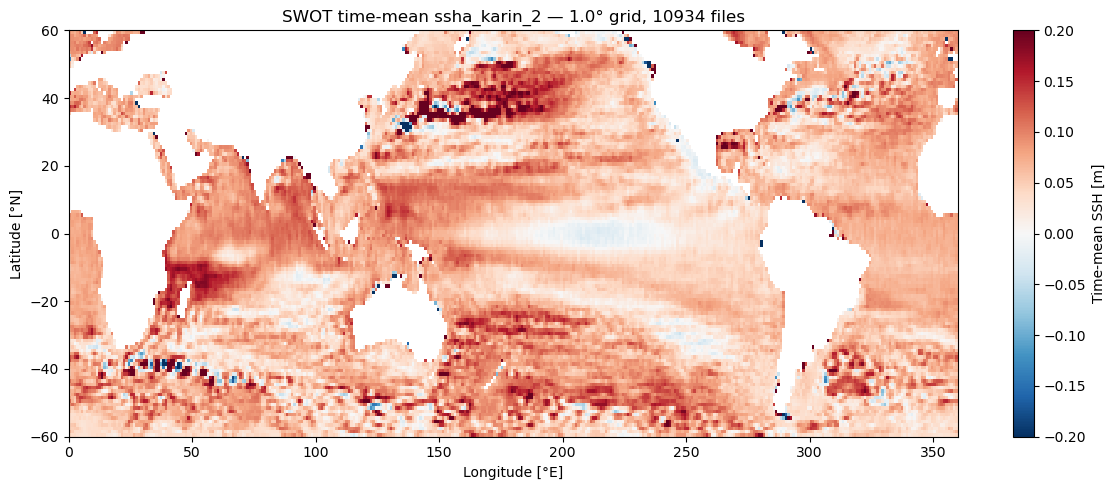

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
pcm = ax.pcolormesh(ds_mean['lon'], ds_mean['lat'], ds_mean['ssh_mean'],
                     cmap='RdBu_r', vmin=-0.2, vmax=0.2, shading='auto')
fig.colorbar(pcm, ax=ax, label='Time-mean SSH [m]')
ax.set_xlabel('Longitude [°E]')
ax.set_ylabel('Latitude [°N]')
ax.set_title(f'SWOT time-mean {SSH_VAR} — {GRID_DEG}° grid, '
             f'{len(filepaths) - len(skipped)} files')
fig.tight_layout()


## 9. Save

Save the mean now so it can be reloaded later without re-reading a year of
raw granules. To compute SSHA variance in a follow-up notebook: reload this
file, and for every new pass, bin its `ssha` the same way, subtract
`ssh_mean` at each matching grid cell to get the anomaly relative to this
time mean, then accumulate `sum(anomaly**2)` and `count` per cell the same
streaming way used here — `variance = sum_sq_total / count_total` at the end.


In [15]:
ds_mean.to_netcdf(OUTPUT_NC)
print(f'Saved time-mean SSH to: {OUTPUT_NC}')


Saved time-mean SSH to: swot_ssh_time_mean_0424_0425.nc


In [16]:
# Shut down the cluster when done.
client.close()
cluster.close()


2026-07-22 16:39:42,069 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File 